**Hidden Markov Model**

Paulo Yoshio Kuga

In this notebook, we are going to show how to train the HMM model with lissa.

In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

import json
from sklearn.mixture import GaussianMixture

In [2]:
#You also can read data without processing it always:

total_data = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
total_data["time"] = pd.to_datetime(total_data["time"])
total_data.set_index("time",inplace=True)

/tmp/ipykernel_68268/3032592086.py:3: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  total_data = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


Then, a list of properties is obtained through copy and paste of previous $list(entireData)$

In [3]:
with open("./dictionaries/new_headers.json") as dict:
    operational_headers = json.load(dict)["numerical_headers"]

pumpList = total_data["Well Run"].unique()

In [4]:
main_seed = 19971215
np.random.seed(main_seed)

total_data["Choke Closed"] = 1-total_data["Choke Opening"]
total_data["Radius"] = total_data[operational_headers].pow(2).sum(axis=1).pow(1/2)

X_train, train_length, X_test, test_length, model_data, total_length = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=total_data)

In [5]:
n = 3
radiusData = X_train["Radius"].loc[X_train["Well_down"]==0]
radius_data_np = li.check_data(radiusData)

model_gmm = GaussianMixture(n_components=n,random_state=main_seed)
model_gmm.fit(radius_data_np)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,19971215


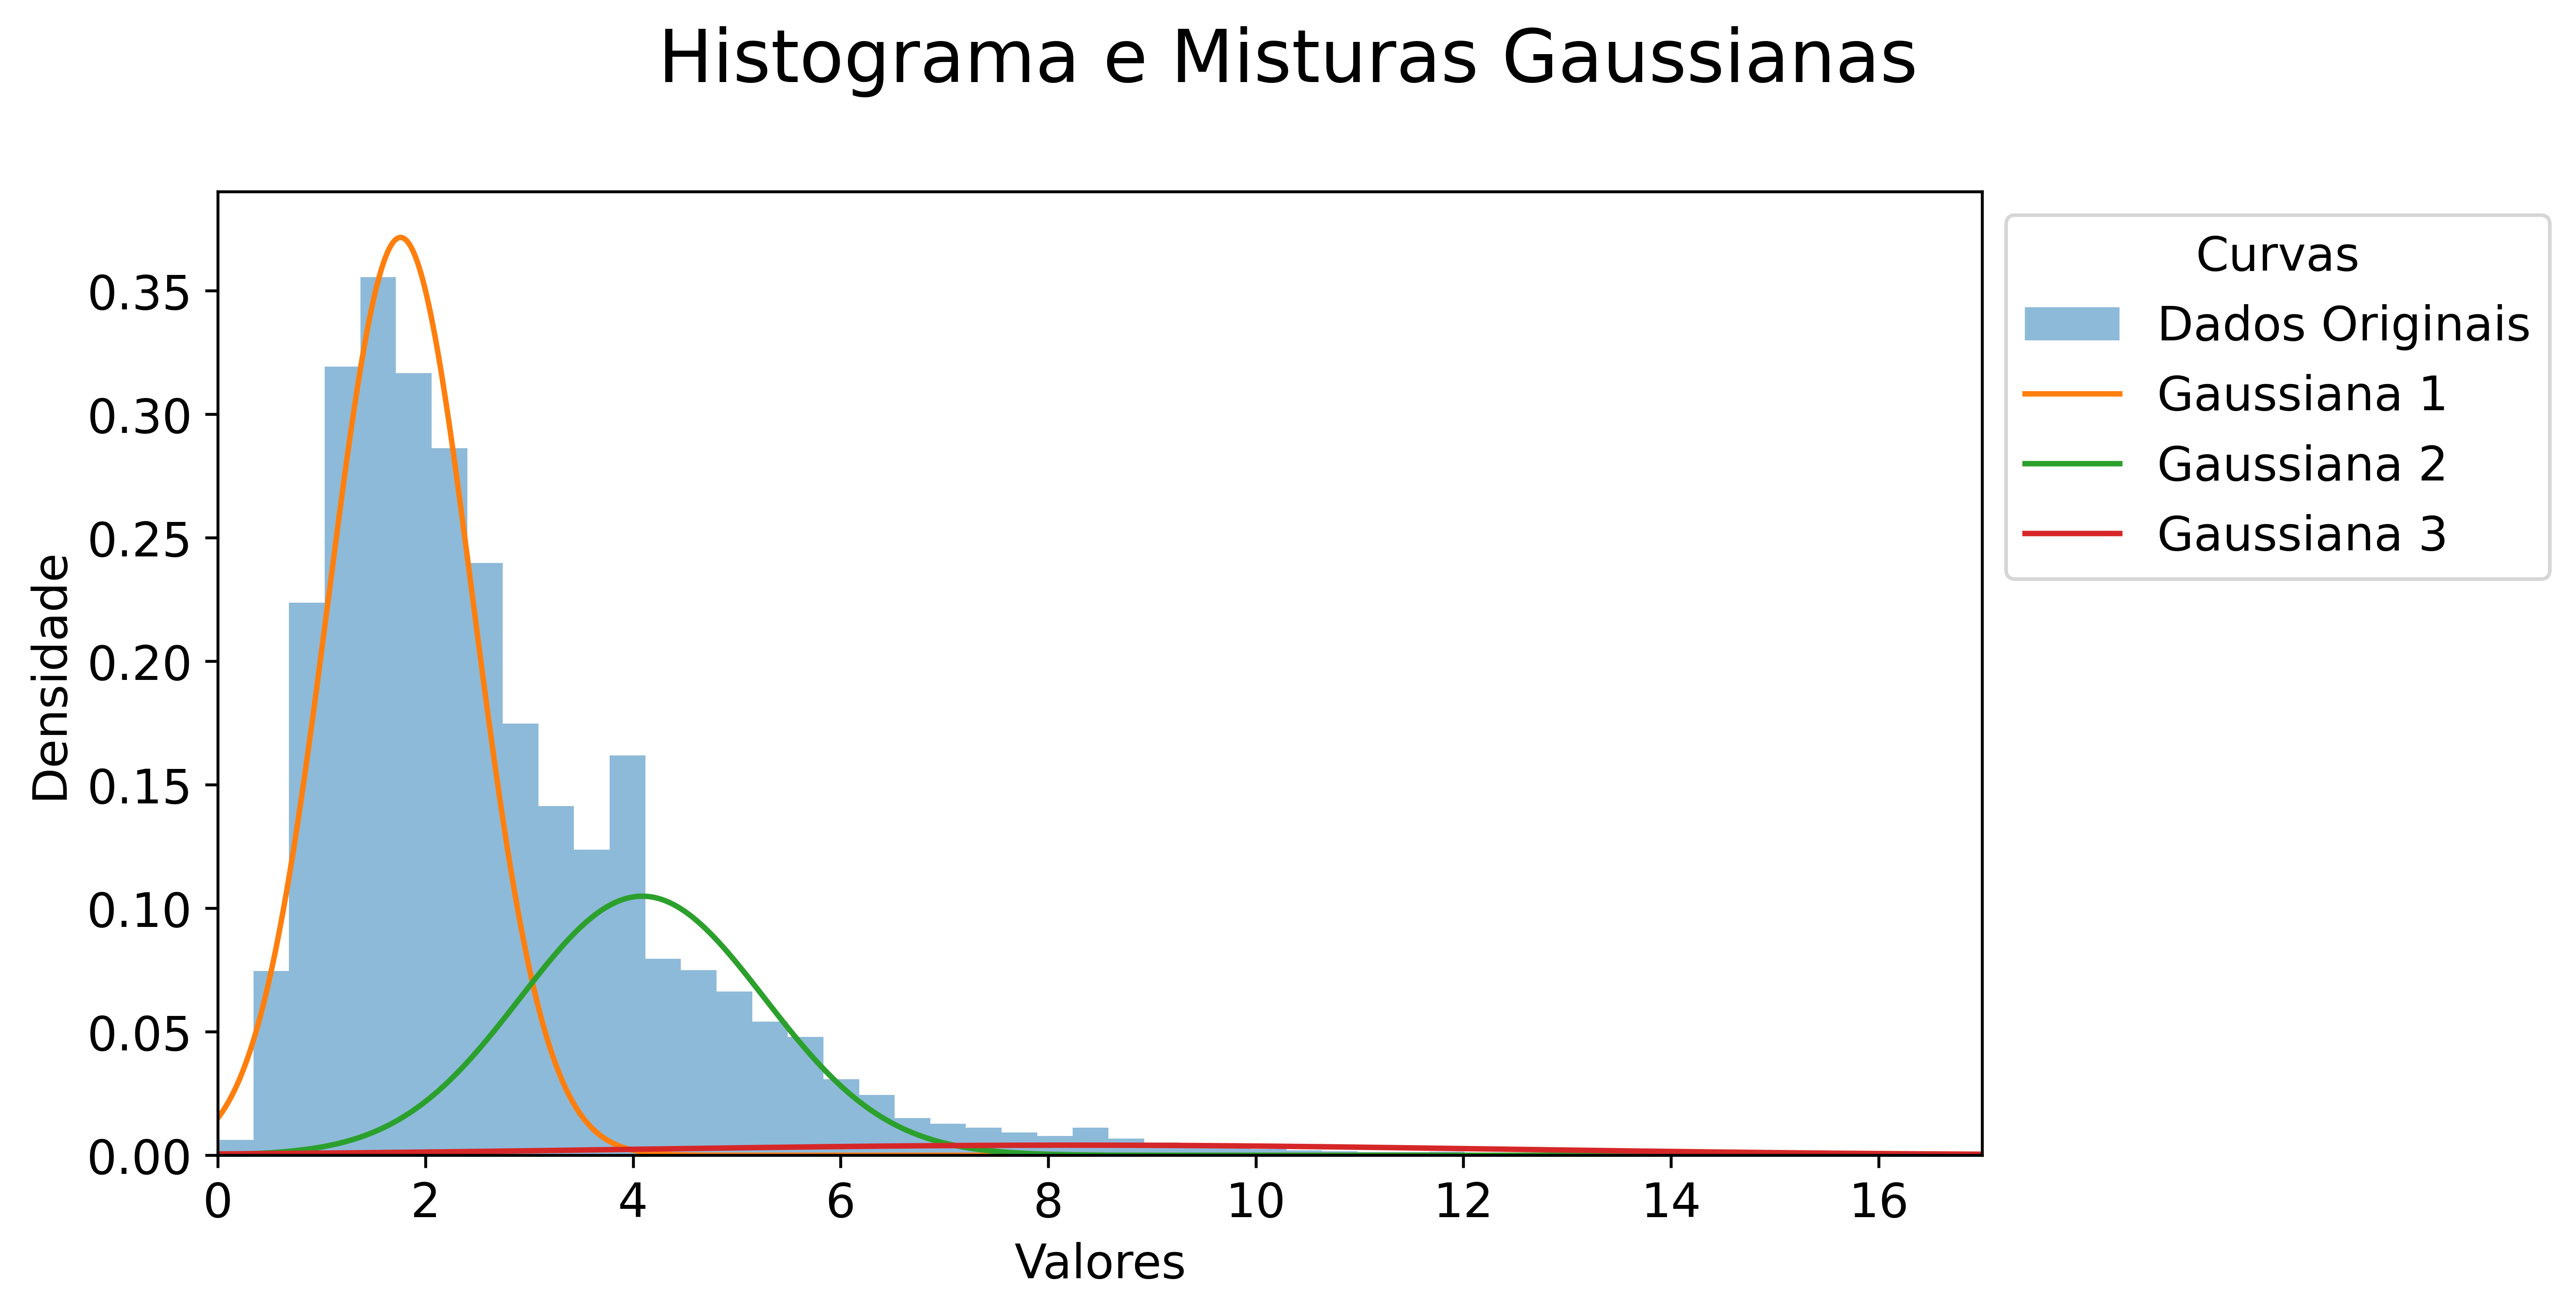

In [6]:
nomes = []

nomes.append("Dados Originais")

for i in range(0,n):
    nomes.append(f"Gaussiana {i+1}")


figure = (li.LissaFigure("./plots/gaussian_mixture.json")
 .set_figure()
 .plot_gmm_histogram(model_gmm,radius_data_np)
 .set_axes_texts()
 .set_legends(columns=nomes)
 .finalize()
 .save_fig()
 )

In [7]:
model_hmm = hmm.GaussianHMM(
    n_components=n,
    random_state=main_seed,
    covariance_type="full",
    #params="st",
    init_params="st",
    algorithm="viterbi"
    )

model_hmm.means_ = model_gmm.means_
model_hmm.covars__ = model_gmm.covariances_

model_hmm.fit(li.check_data(X_train["Radius"]),train_length)

print(f"AIC:  {model_hmm.aic(li.check_data(X_train["Radius"]),train_length)} BIC: {model_hmm.bic(li.check_data(X_train["Radius"]),train_length)}")

AIC:  1284295.192721413 BIC: 1284453.0446008933


In [8]:
total_data, model_data = li.PostProcessing(model_hmm, total_data, model_data,"Radius", "State Radius", total_length)
print(model_hmm.get_stationary_distribution())
total_data["State Radius"] = total_data["State Radius"].map(li.StateConversion(model_hmm.get_stationary_distribution(),n))



[0.71801597 0.21759493 0.0643891 ]


/tmp/ipykernel_68268/2366960318.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  failure_index = pumpData.index[(pumpData["Failure"]==True).diff().fillna(False)][0]


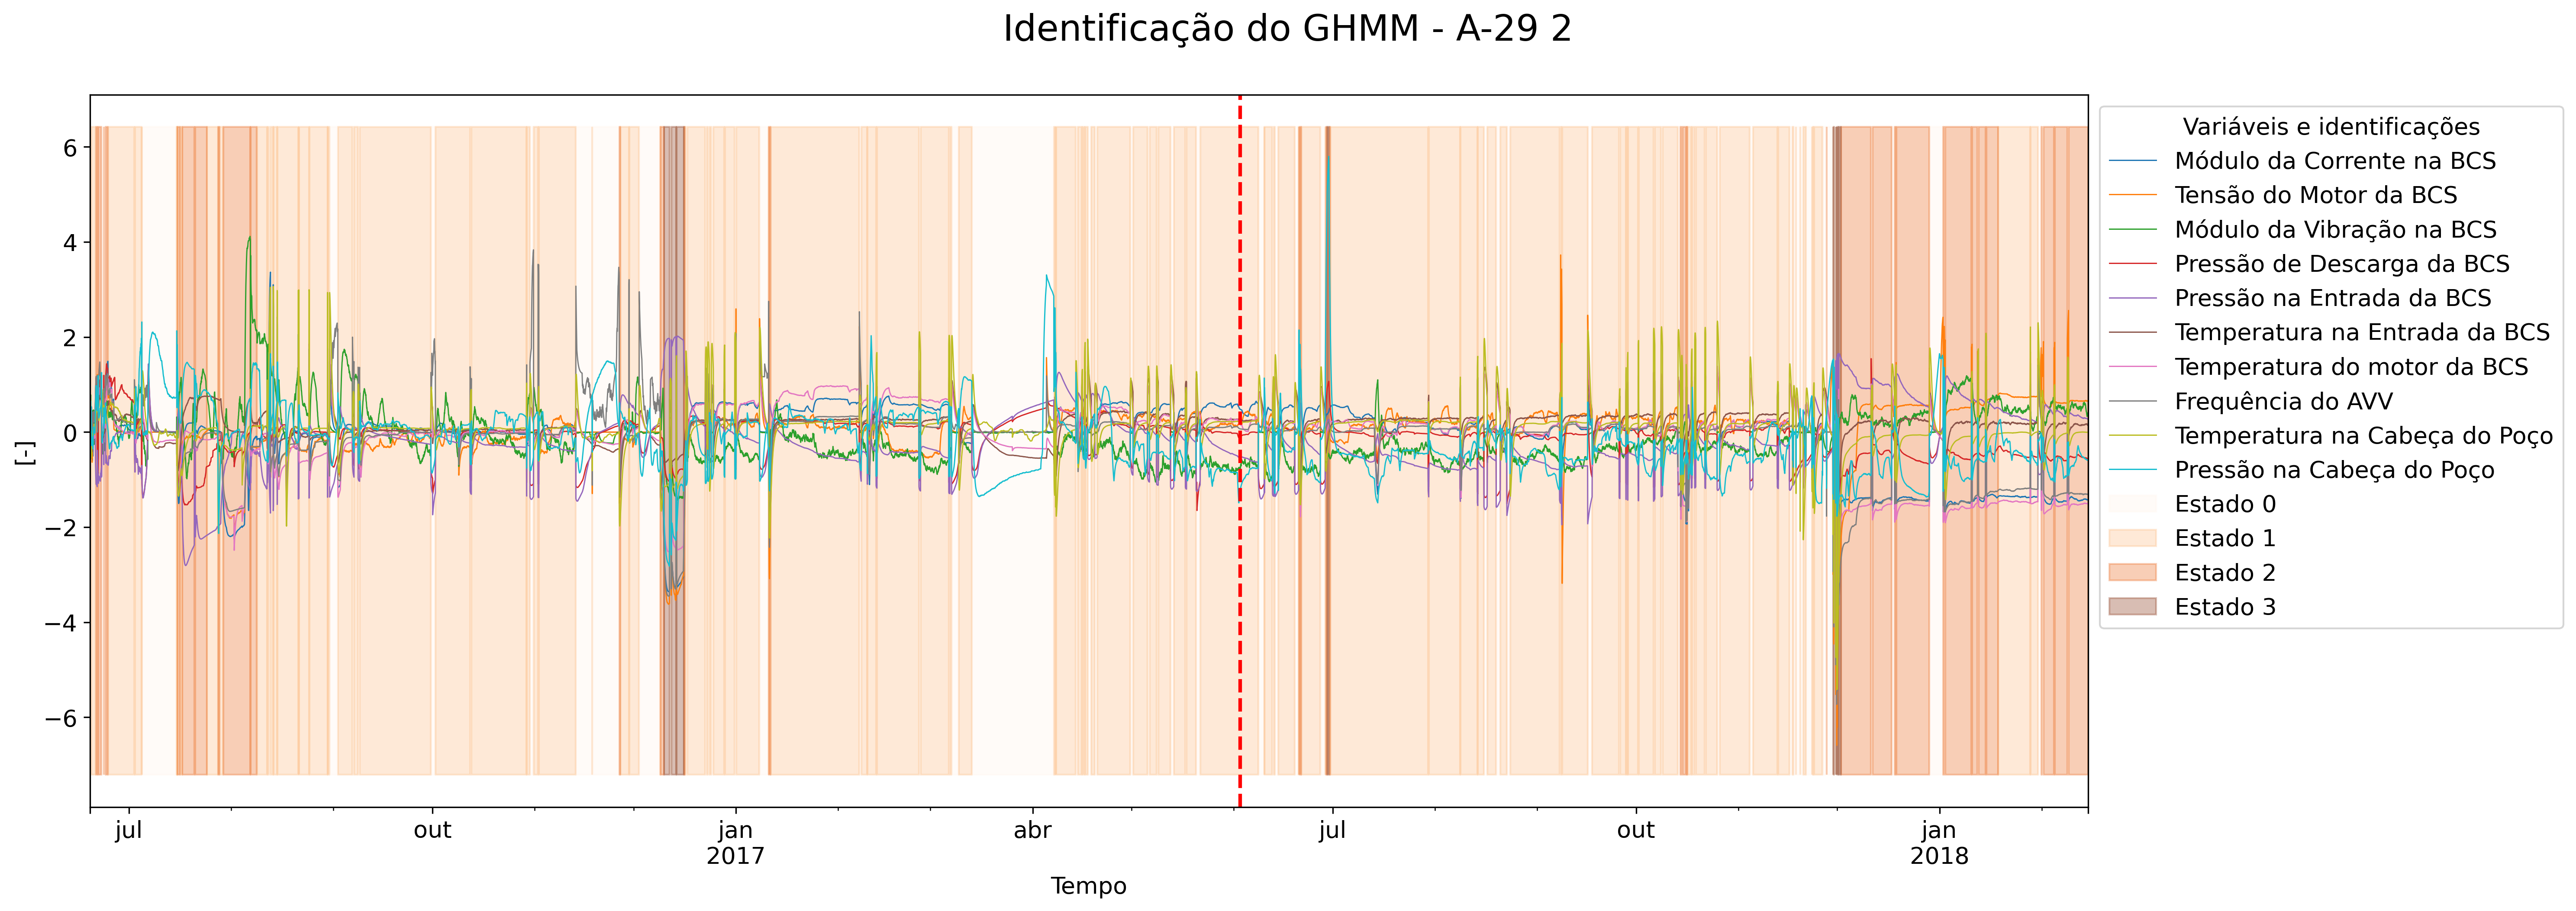

In [9]:
pump = "A-29 2"

#B-18 2
#A-12 2
#A-29 2

pumpData = total_data.loc[total_data["Well Run"]==pump].copy()
pumpData = pumpData.asfreq('h',fill_value=0)

failure_index = pumpData.index[(pumpData["Failure"]==True).diff().fillna(False)][0]

figure = (li.LissaFigure("./plots/hmm_plot.json")
          .set_translation()
          .set_figure()
          .time_series_plot(pumpData)
          .failure_reference(time_entry=failure_index)
          .classification_boundaries(n,pumpData["State Radius"])
          .set_legends()
          .set_axes_texts()
          .finalize())


In [13]:
for pump in pumpList:
    pumpData = total_data.loc[total_data["Well Run"]==pump].copy()
    pumpData = pumpData.asfreq('h',fill_value=0)
    
    figure = (li.LissaFigure("./plots/hmm_plot.json")
          .set_translation()
          .set_figure()
          .time_series_plot(pumpData)
          .failure_reference(time_entry=failure_index)
          .classification_boundaries(n,pumpData["State Radius"])
          .set_legends()
          .set_axes_texts()
          .finalize(title="Identificação do GHMM - "+pump)
          .save_fig(path="../imagens_gerais/pumps/hmm_identification_"+pump))
          
    plt.close()

In [11]:
falhas = np.array([])
for pump in pumpList:#
    pumpData = total_data.loc[(total_data["Well Run"]==pump) & (total_data["Well_down"]==0) ]#.copy()
    
    last = pumpData.shape[0]
    idx = (pumpData["Failure"]==True).diff()
    idx.iloc[0] = False

    if idx.sum()!=0:
        dif = pumpData.index[last-1]-pumpData["time"].loc[idx].index[0]
        falhas = np.append(falhas,dif)

    

KeyError: 'time'

In [ ]:
(falhas > 3).sum()/falhas.shape[0]

0.575

In [ ]:
medianListR = np.array([])

for pump in X_test["Well Run"].unique():#pumpList:#
    pumpData = total_data.loc[(total_data["Well Run"]==pump) & (total_data["Well_down"]==0) ]#.copy()
    last = pumpData.shape[0]
    pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
    medianListR = np.append(medianListR,pumpMedianR)




In [ ]:
counts[[1,2]]

array([22, 16])

In [ ]:
counts[2]/counts.sum()

0.2807017543859649

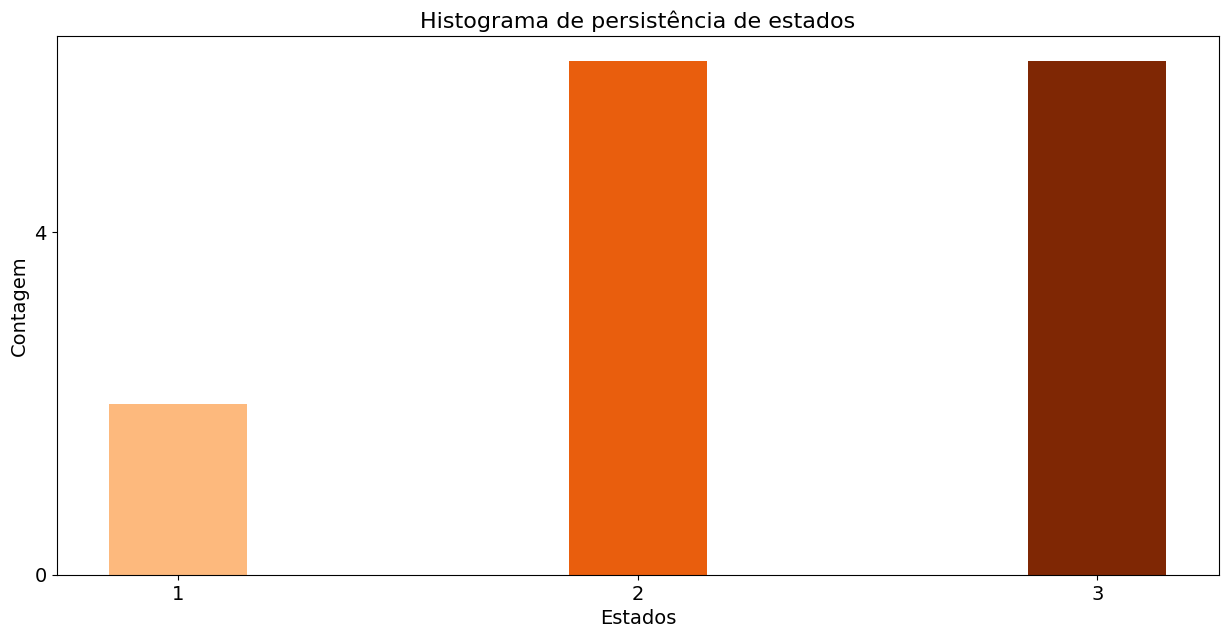

In [ ]:
cmap = plt.get_cmap('Oranges', n+1)
plt.rcParams["font.size"] = 14
fig,axs=plt.subplots(1,1,figsize=(15,7))
states,counts = np.unique(medianListR,return_counts=True)
axs.bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs.set_xticks(states,np.int64(states))
axs.set_yticks(range(int(0), int(max(counts))+1,4))
axs.set_ylabel("Contagem")
axs.set_xlabel("Estados")
axs.set_title("Histograma de persistência de estados",fontsize=16)


plt.savefig("../imagens_gerais/radius_histogram_xtest.jpg")

In [ ]:
model.weights_

array([0.63381229, 0.31874   , 0.04744771])

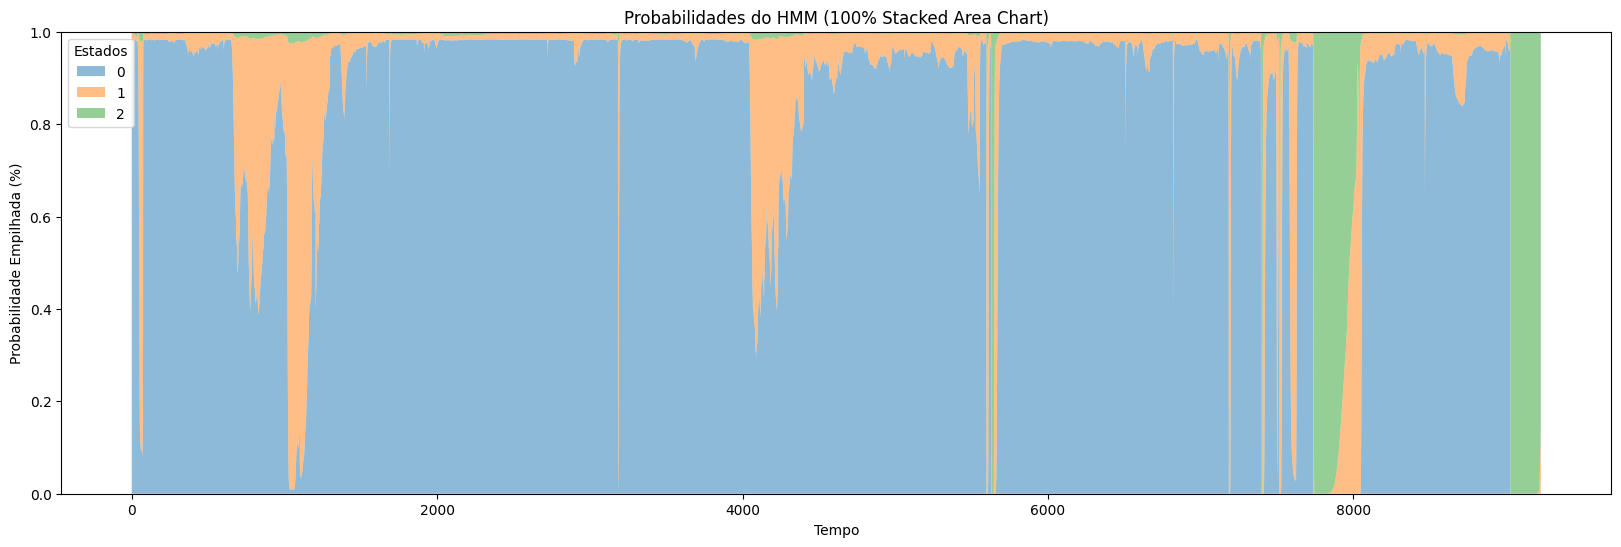

In [ ]:
li.PlotHMMProbs(total_data["Radius"].loc[(total_data["Well_down"]==0) & (total_data["Well Run"]==pumpList[0])],model)

In [ ]:
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1]]) # Substituir pelos valores reais
expected_counts = np.array([1/2, 1/2]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 0.0270, p-valor: 0.8694
Não há evidências suficientes para afirmar que C ocorre mais que o esperado.


In [ ]:
# cmap = plt.get_cmap('Oranges', n)
# plt.figure(figsize=(7,5))

# states,counts = np.unique(medianListR,return_counts=True)
# plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
# plt.xticks(states,np.int64(states))
# plt.ylabel("Counts")
# plt.xlabel("States")
# plt.title("Vibration Modulus Persistence Histogram")
# plt.savefig("../imagens_gerais/vibration_histogram.jpg")

In [ ]:
# # Contagens das classes ao longo das inicializações
# observed_counts = counts  # Substituir pelos valores reais
# expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# # Teste qui-quadrado de aderência
# chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

# print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

# if p_value < 0.05:
#     print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
# else:
#     print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


In [ ]:
for pump in pumpList:
   
    pumpData = total_data.loc[total_data["Well Run"]==pump].copy()

    # fig, axs =li.HMMPicture(
    #     pumpData,
    #     pump,
    #     props=[PCAHeaders,vibeHeader],
    #     states=["State Radius","State Mod"],
    #     numberOfStates=n,
    #     figsize=(40,15)
    #     )

    # fig.savefig("../imagensFinaisHMM/heatmap-"+pump+".png")
    # plt.close()
    onlineData = pumpData.loc[pumpData["Well_down"]==0]
    plt.figure(figsize=(10,10))
    plt.scatter(onlineData["Water Cut @ 20degC - 1 atm"],onlineData["Choke Closed"],c=onlineData["State Radius"],s=onlineData["Radius"])
    plt.xlabel("Water Cut @ 20degC - 1 atm")
    plt.ylabel("Choke Closed")
    plt.savefig("../choke_per_watercut/"+pump+".png")
    plt.close()


Text(0, 0.5, 'Choke Closed')

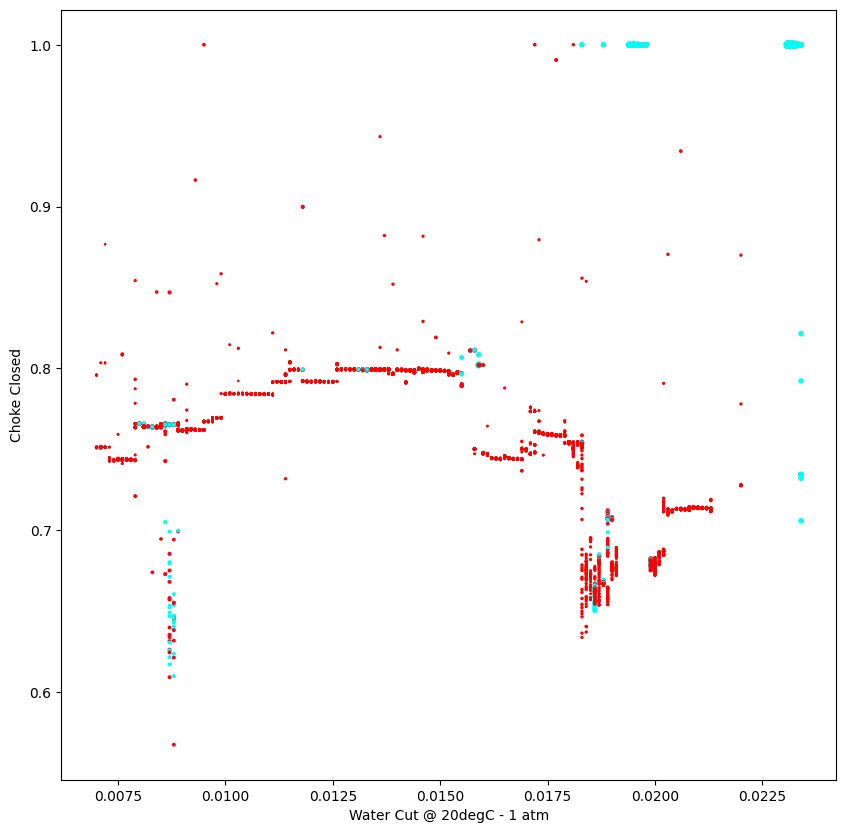

In [ ]:
onlineData = total_data.loc[(total_data["Well_down"]==0) & (total_data["Well Run"]==pumpList[0]) ]

x = onlineData["Water Cut @ 20degC - 1 atm"]#.apply(np.exp))
y = onlineData["Choke Closed"]#.apply(np.exp))

plt.figure(figsize=(10,10))
plt.scatter(x,y,c=onlineData["State Radius"],s=onlineData["Radius"],cmap='hsv')
plt.xlabel("Water Cut @ 20degC - 1 atm")
plt.ylabel("Choke Closed")
# plt.savefig("../choke_per_watercut/"+pump+".png")
# plt.close()

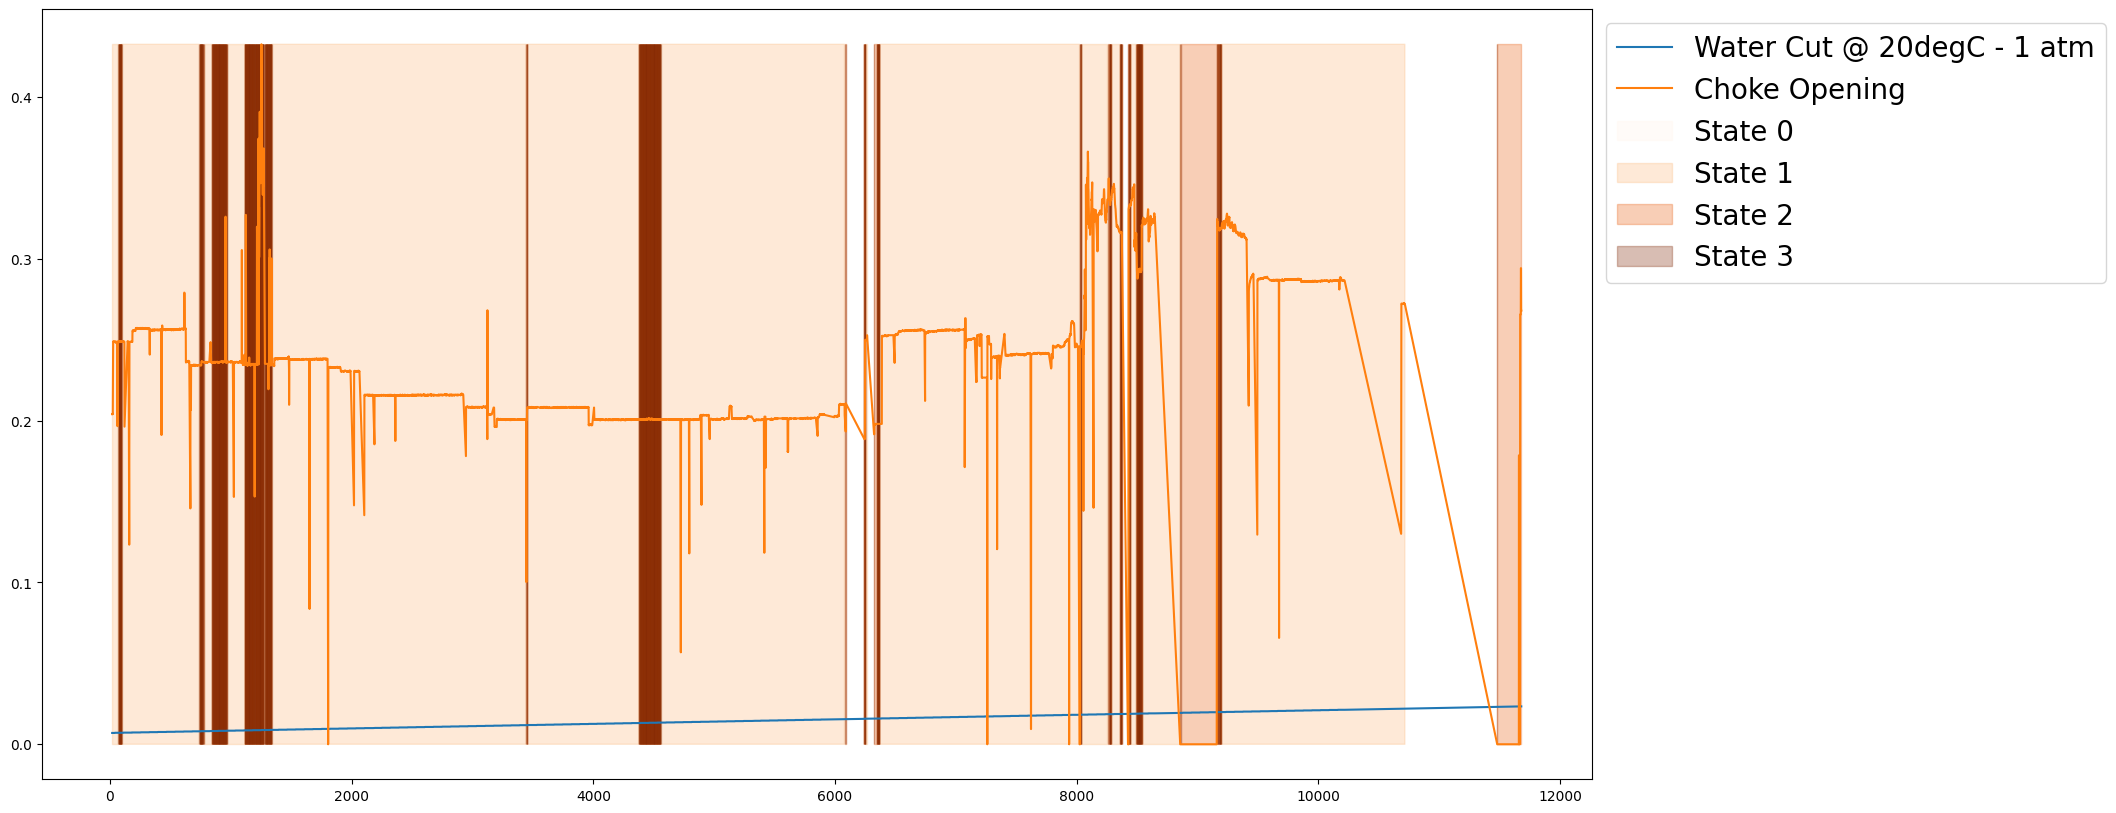

In [ ]:
fig,axs = plt.subplots(1,1,figsize=(20,10))

onlineData[["Water Cut @ 20degC - 1 atm","Choke Opening"]].plot(ax=axs)
li.OverFill(onlineData,["Water Cut @ 20degC - 1 atm","Choke Opening"],"State Radius",3,axs)
#.pow(2).sum(axis=1).pow(1/2).div(np.sqrt(2))